# Fine-tuning Qwen2.5-VL for Object Detection using Maestro

---

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow/maestro/blob/develop/cookbooks/maestro_qwen2_5_vl_object_detection.ipynb)
[![discord](https://img.shields.io/discord/1159501506232451173?logo=discord&label=discord&labelColor=fff&color=5865f2&link=https%3A%2F%2Fdiscord.gg%2FGbfgXGJ8Bk)](https://discord.gg/GbfgXGJ8Bk)

Join our Discord for community support on Vision-Language Models. If you enjoy it, ⭐ [Maestro GitHub](https://github.com/roboflow/maestro).

### Configure your API keys

To fine-tune Qwen2.5-VL, you need to provide your HuggingFace Token and Roboflow API key. Follow these steps:

- Open your [`HuggingFace Settings`](https://huggingface.co/settings) page. Click `Access Tokens` then `New Token` to generate new token.
- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑).
    - Store HuggingFace Access Token under the name `HF_TOKEN`.
    - Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

In [1]:
import os

from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `A100 GPU`, and then click `Save`.

In [2]:
!nvidia-smi

Tue Feb 25 14:07:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Install dependencies

In [ ]:
!pip install -q "maestro[qwen_2_5_vl]==1.1.0rc3"

## Download and prepare dataset

The dataset is sourced from Roboflow and is structured in COCO format. Using the Roboflow API, we authenticate, and download the dataset.

In [4]:
from roboflow import download_dataset

dataset = download_dataset("https://app.roboflow.com/roboflow-jvuqo/circuit-voltages-udmgw/1", "coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to circuit-voltages-1 in coco:: 100%|██████████| 140/140 [00:00<00:00, 4415.16it/s]


In [5]:
SYSTEM_MESSAGE = "You are a helpful assistant."
MIN_PIXELS = 512 * 28 * 28
MAX_PIXELS = 1280 * 28 * 28

## Train Qwen2.5-VL with maestro

The training process is initiated using Maestro's `train` function. The training is run using 10 epochs with a batch size of 4. The optimization strategy used is `qlora`, which allows for efficient fine-tuning of large models. The metrics tracked during training are `edit_distance` and `mean_average_precision`. Specifically, `edit_distance` is computed on the raw text output from the Qwen2.5-VL model, providing a direct measure of textual accuracy against the expected output. Meanwhile, `mean_average_precision` is a metric familiar from traditional object detection tasks; in this context, it is computed based on the parsed output, ensuring that both the identification and the localization of elements are accurately quantified.








In [ ]:
from maestro.trainer.models.qwen_2_5_vl.core import train

config = {
    "model_id": "Qwen/Qwen2.5-VL-3B-Instruct",
    "dataset": dataset.location,
    "system_message": SYSTEM_MESSAGE,
    "min_pixels": MIN_PIXELS,
    "max_pixels": MAX_PIXELS,
    "epochs": 20,
    "batch_size": 2,
    "num_workers": 10,
    "optimization_strategy": "qlora",
    "metrics": ["edit_distance", "mean_average_precision"],
}

train(config)

In [7]:
!ls -la /content/training/qwen_2_5_vl/1/metrics

total 200
drwxr-xr-x 2 root root  4096 Feb 25 15:11 .
drwxr-xr-x 4 root root  4096 Feb 25 15:11 ..
-rw-r--r-- 1 root root 37476 Feb 25 15:11 edit_distance_plot.png
-rw-r--r-- 1 root root 29584 Feb 25 15:11 loss_plot.png
-rw-r--r-- 1 root root 38257 Feb 25 15:11 map50:95_plot.png
-rw-r--r-- 1 root root 34004 Feb 25 15:11 map50_plot.png
-rw-r--r-- 1 root root 41400 Feb 25 15:11 map75_plot.png


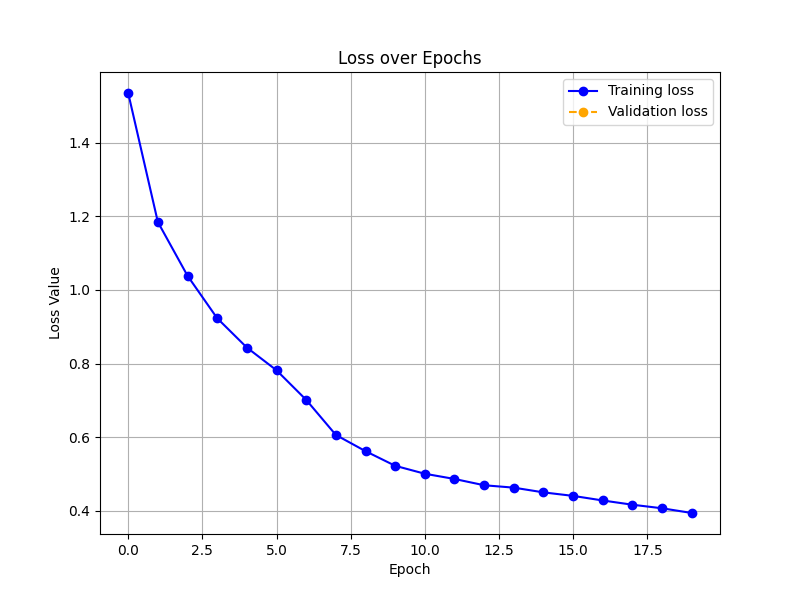

In [8]:
from IPython.display import Image

Image(filename="/content/training/qwen_2_5_vl/1/metrics/loss_plot.png", height=600)

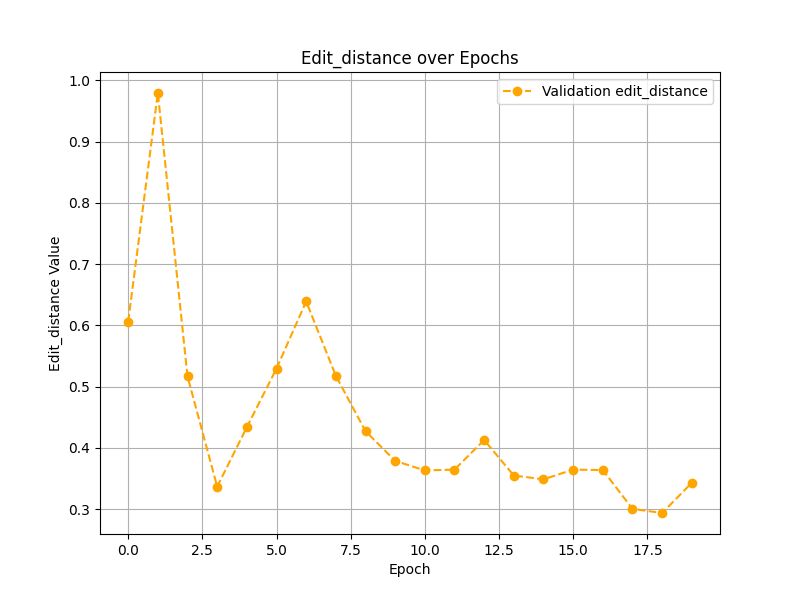

In [9]:
from IPython.display import Image

Image(filename="/content/training/qwen_2_5_vl/1/metrics/edit_distance_plot.png", height=600)

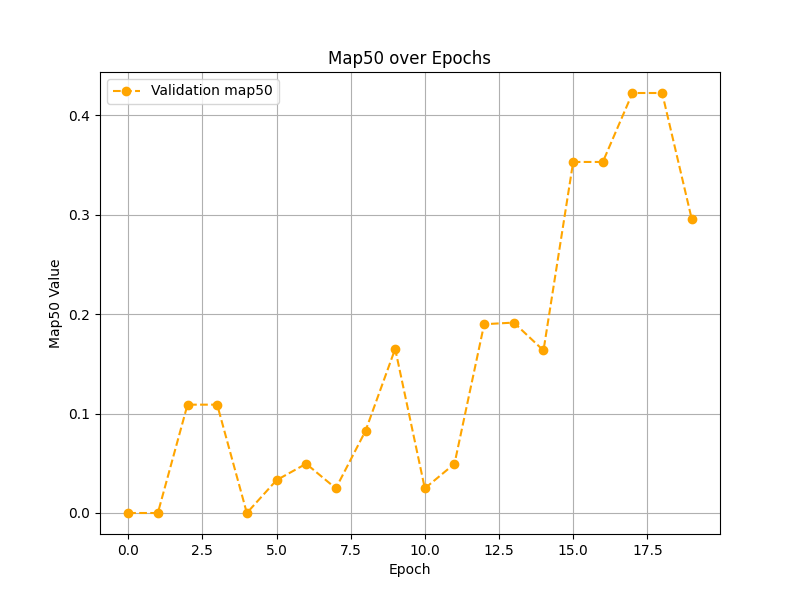

In [35]:
from IPython.display import Image

Image(filename="/content/training/qwen_2_5_vl/1/metrics/map50_plot.png", height=600)

## Run inference with fine-tuned Qwen2.5-VL model

We load the fine-tuned Qwen2.5-VL model and run inference on test images. The `predict` function generates detections in JSON format, which is parsed and verified for correctness.


In [11]:
from maestro.trainer.models.qwen_2_5_vl.checkpoints import load_model

processor, model = load_model(
    model_id_or_path="/content/training/qwen_2_5_vl/1/checkpoints/latest",
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
)

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [38]:
from functools import partial

from maestro.trainer.common.datasets.coco import COCODataset, COCOVLMAdapter
from maestro.trainer.models.qwen_2_5_vl.detection import detections_to_prefix_formatter, detections_to_suffix_formatter

coco_dataset = COCODataset(
    annotations_path=f"{dataset.location}/test/_annotations.coco.json", images_directory_path=f"{dataset.location}/test"
)

qwen2_5_dataset = COCOVLMAdapter(
    coco_dataset=coco_dataset,
    prefix_formatter=detections_to_prefix_formatter,
    suffix_formatter=partial(detections_to_suffix_formatter, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS),
)

image, entry = qwen2_5_dataset[0]

[INFO] maestro - Loaded 15 valid entries out of 15 from '/content/circuit-voltages-1/test/_annotations.coco.json'. Skipped 0. Found 0 entries with empty detections.


In [39]:
from maestro.trainer.models.qwen_2_5_vl.inference import predict

generated_suffix = predict(model=model, processor=processor, image=image, prefix=entry["prefix"], system_message=None)

In [40]:
print(generated_suffix)

```json
[
	{"bbox_2d": [598, 107, 743, 168], "label": "Resistor"},
	{"bbox_2d": [274, 278, 413, 432], "label": "Voltage DC"},
	{"bbox_2d": [610, 480, 766, 597], "label": "Resistor"}
]
```


In [41]:
import supervision as sv
from qwen_vl_utils import smart_resize

image_w, image_h = image.size
input_h, input_w = smart_resize(height=image_h, width=image_w, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)

targets = sv.Detections.from_vlm(
    vlm=sv.VLM.QWEN_2_5_VL,
    result=entry["suffix"],
    input_wh=(input_w, input_h),
    resolution_wh=(image_w, image_h),
    classes=coco_dataset.classes,
)
predictions = sv.Detections.from_vlm(
    vlm=sv.VLM.QWEN_2_5_VL,
    result=generated_suffix,
    input_wh=(input_w, input_h),
    resolution_wh=(image_w, image_h),
    classes=coco_dataset.classes,
)

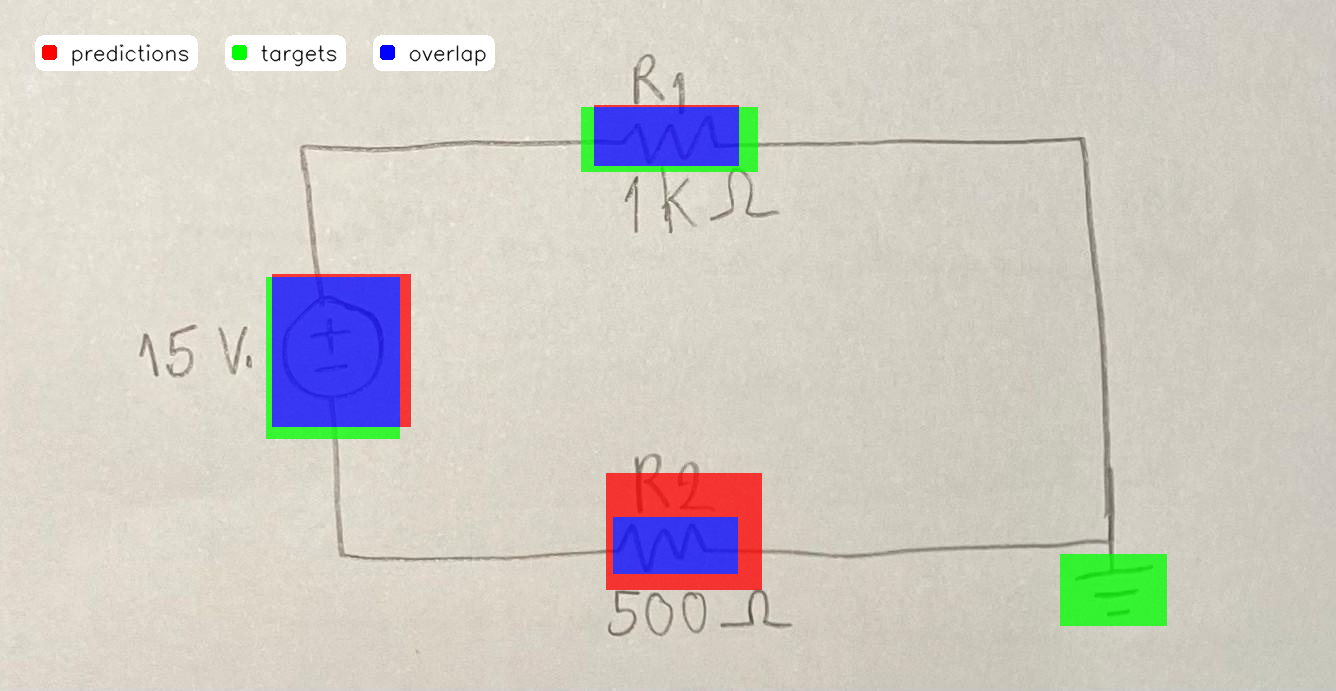

In [42]:
annotated_frame = image.copy()

comparison_annotator = sv.ComparisonAnnotator(
    label_1="predictions", label_2="targets", label_overlap="overlap", label_scale=0.7
)

annotated_frame = comparison_annotator.annotate(scene=annotated_frame, detections_1=predictions, detections_2=targets)

annotated_frame

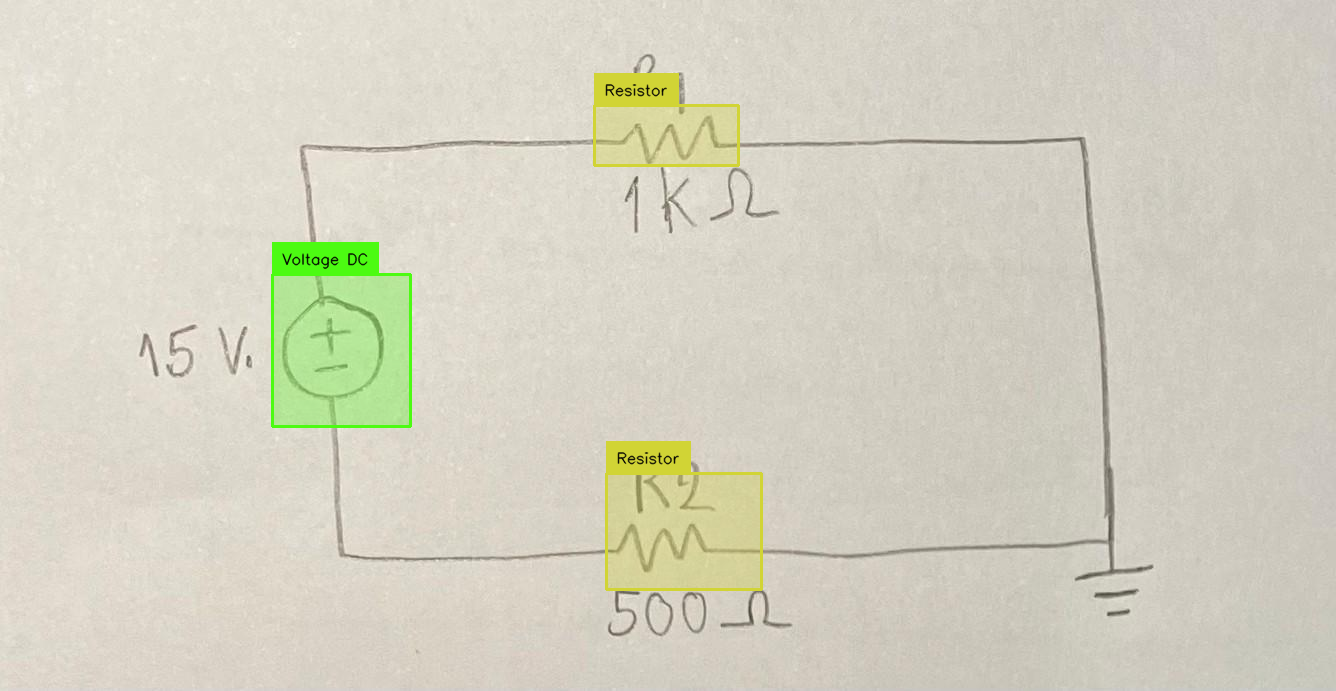

In [43]:
annotated_frame = image.copy()

color_annotator = sv.ColorAnnotator(opacity=0.3)
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_frame = color_annotator.annotate(scene=annotated_frame, detections=predictions)
annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=predictions)
annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=predictions)

annotated_frame

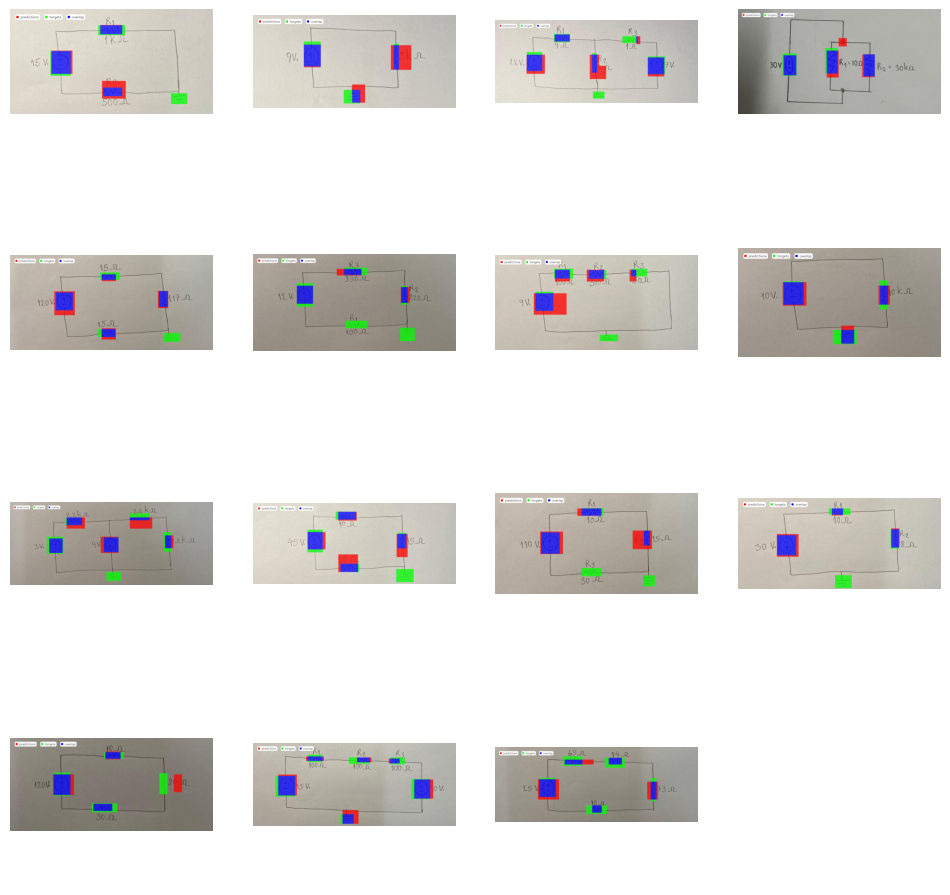

In [16]:
annotated_frames = []

comparison_annotator = sv.ComparisonAnnotator(
    label_1="predictions", label_2="targets", label_overlap="overlap", label_scale=0.7
)

for image, entry in qwen2_5_dataset:
    image_w, image_h = image.size
    input_h, input_w = smart_resize(height=image_h, width=image_w, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)

    generated_suffix = predict(
        model=model, processor=processor, image=image, prefix=entry["prefix"], system_message=None
    )

    targets = sv.Detections.from_vlm(
        vlm=sv.VLM.QWEN_2_5_VL,
        result=entry["suffix"],
        input_wh=(input_w, input_h),
        resolution_wh=(image_w, image_h),
        classes=coco_dataset.classes,
    )
    predictions = sv.Detections.from_vlm(
        vlm=sv.VLM.QWEN_2_5_VL,
        result=generated_suffix,
        input_wh=(input_w, input_h),
        resolution_wh=(image_w, image_h),
        classes=coco_dataset.classes,
    )

    annotated_frame = comparison_annotator.annotate(scene=image.copy(), detections_1=predictions, detections_2=targets)
    annotated_frames.append(annotated_frame)

sv.plot_images_grid(annotated_frames, grid_size=(4, 4))

## More Vision-Language Models

Now that you have fine-tuned Qwen2.5-VL for object detection, why not experiment with other vision-language models and different vision tasks? You can explore more at [Maestro Documentation](https://maestro.roboflow.com/) or the [Maestro GitHub](https://github.com/roboflow/maestro). If you find a bug or have feature ideas, submit an issue at [GitHub Issues](https://github.com/roboflow/maestro/issues).